# Data Preprocessing and Exploration

In [1]:
import pandas as pd
import geopandas as gpd
import pyarrow
from datetime import datetime, timedelta
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import seaborn as sns
from shapely.geometry import Point
from shapely.ops import nearest_points

## 1. Importing Datasets

Original 'dirty' datasets retrieved from AWS s3 bucket and aed dataset with geocoded addresses retrieved from public GitHub Repository.

In [ ]:
# Setting parameters for papermill
url = 's3://mdaprojectdata2/'
url2 = 'https://raw.githubusercontent.com/JeroenGuillierme/Project-MDA/main/Data/'
output_data_path = 'Results/preprocessed_data.csv'

In [2]:
ambulance = pd.read_parquet(f'{url}ambulance_locations.parquet.gzip')
pit = pd.read_parquet(f'{url}pit_locations.parquet.gzip')
interventions1 = pd.read_parquet(f'{url}interventions1.parquet.gzip')
interventions2 = pd.read_parquet(f'{url}interventions2.parquet.gzip')
interventions3 = pd.read_parquet(f'{url}interventions3.parquet.gzip')
interventions4 = pd.read_parquet(f'{url}interventions_bxl.parquet.gzip')
interventions5 = pd.read_parquet(f'{url}interventions_bxl2.parquet.gzip')
cad = pd.read_parquet(f'{url}cad9.parquet.gzip')
aed = pd.read_parquet(f'{url}aed_locations.parquet.gzip')

aed_total = pd.read_csv(f'{url2}aed_total_coordinates.csv')
mug1 = pd.read_csv(f'{url2}mug1.csv')

# Load Belgium with regions shapefile
belgium_with_provinces_boundary = gpd.read_file(f'{url2}BELGIUM_-_Provinces.geojson')

# External PIT data with their latitudes and longitudes
pit_locations = pd.read_excel(f'{url2}pit_01022024_fr.xlsx')

pd.set_option('display.max_columns', None)
pd.options.mode.copy_on_write = True

In [3]:
# Ensure the CRS (Coordinate Reference System) is set to WGS84 (latitude/longitude)
belgium_with_provinces_boundary = belgium_with_provinces_boundary.to_crs(4326)

## 2. Functions

Here some custom functions are imported from the Functions.py script, which will be used further in this Notebook for preprocessing/cleaning the data.

In [2]:
from Functions import (correct_latitude, correct_longitude, is_within_belgium, assign_province, assign_nearest_province, 
convert_format1, convert_format2, convert_format3, extract_numeric, timedelta_to_minutes, draw_histograms)

## 3. Preprocessing Interventions Datasets

### 3.1 Intervention datasets one till three

1) Only cardiac arrest incidents are kept in the datasets.
2) Time variables converted to datetime.
3) Conctenate first three intervention datasets together.
4) Create new variable for response time: T3-T0.
5) Correct format of the latitude and longitude coordinates.
6) Rename variables Eventlevel and EventType.
7) Select only several number of variable to go further with.

In [5]:
# only keeping cardiac arrest interventions
interventions1 = interventions1[interventions1["EventType Firstcall"] == "P003 - Cardiac arrest"]
interventions2 = interventions2[interventions2["EventType Firstcall"] == "P003 - Cardiac arrest"]
interventions3 = interventions3[interventions3["EventType Firstcall"] == "P003 - Cardiac arrest"]

In [6]:
# Converting time formats to datetime 
# T0
interventions1["T0"] = interventions1["T0"].apply(convert_format1)
interventions2["T0"] = interventions2["T0"].apply(convert_format1)
interventions3["T0"] = interventions3["T0"].apply(convert_format1)

# T3
interventions1["T3"] = interventions1["T3"].apply(convert_format2)
interventions2["T3"] = interventions2["T3"].apply(convert_format2)
interventions3["T3"] = interventions3["T3"].apply(convert_format2)


In [7]:
# Concatenating first three intervention datasets
interventions123_total = pd.concat([interventions1, interventions2, interventions3], axis=0)

# Creating response time variable T3-T0, after converting them in the right date-time format
interventions123_total["T3-T0"] = interventions123_total["T3"] - interventions123_total["T0"]

# Creating new variable Intervention (binary indicator)
interventions123_total['Intervention'] = 1

# Correcting coordinates
interventions123_total['Latitude'] = interventions123_total['Latitude intervention'].apply(correct_latitude).copy()
interventions123_total['Longitude'] = interventions123_total['Longitude intervention'].apply(correct_longitude).copy()

# Renaming variable Eventlevel
interventions123_total['Eventlevel'] = interventions123_total["EventLevel Firstcall"].copy()


# Renaming variable EventType
interventions123_total['EventType'] = interventions123_total['EventType Firstcall']

# Only keep several variables
interventions123_total = interventions123_total[
    ['Mission ID', 'Latitude', 'Longitude', "Intervention", "Eventlevel", "T3-T0", "EventType", "Vector type", "Province intervention"]]

In [8]:
interventions123_total.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,Province intervention
42,10221520047,51.20685,5.13662,1,N1,0 days 00:18:53.095000,P003 - Cardiac arrest,MUG,ANT
87,10221520095,51.24848,4.43869,1,N1,0 days 00:04:14.322000,P003 - Cardiac arrest,Ambulance,ANT
88,10221520095,51.24848,4.43869,1,N1,0 days 00:12:36.753000,P003 - Cardiac arrest,MUG,ANT
207,10221520224,51.28273,4.42134,1,N1,0 days 00:13:25.674000,P003 - Cardiac arrest,MUG,ANT
208,10221520224,51.28273,4.42134,1,N1,0 days 00:36:37.170000,P003 - Cardiac arrest,Ambulance,ANT


### 3.2 cad dataset

1. Only cardiac arrest are kept in the cad dataset.
2. Time variableconverted to datetime.
3. Creating new variables: Intervention (Binary indicator) and T3-T0 (response time).
4. Renaming variables Eventlevel, Vector type and Province intervention.
5. Correct format of the latitude and longitude coordinates.
6. Select only several number of variables to go further with.

In [9]:
# Only keep cardiac arrest incidents
cad = cad[cad['EventType Trip'] == "P003 - HARTSTILSTAND - DOOD - OVERLEDEN"]

In [10]:
# Converting time formats to datetime 
# T0
cad["T0"] = cad["T0"].apply(convert_format2)
# T3
cad["T3"] = cad["T3"].apply(convert_format2)

In [11]:
# Create extra column Intervention
cad['Intervention'] = 1 

# Creating new variable response time T3-T0, after converting them in the right date-time format
cad['T3-T0'] = cad['T3'] - cad['T0']

# Renaming variable EventType
cad['EventType'] = cad['EventType Trip']

# Renaming variable EventLevel
cad['Eventlevel'] = cad['EventLevel Trip']

# Renaming variable Vector type
cad['Vector type'] = cad['Vector Type']

# Renaming variable Province intervention
cad['Province intervention'] = cad['Province invervention']

# Correcting coordinates
cad['Latitude'] = cad['Latitude intervention'].apply(correct_latitude)
cad['Longitude'] = cad['Longitude intervention'].apply(correct_longitude)

# Only keep several variables
cad = cad[['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 'EventType', 'Vector type', 'Province intervention']]

In [12]:
cad.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,Province intervention
322,21221530192,50.928019,4.535123,1,N1,-44 days +22:49:37,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,MUG,VBR
323,21221530192,50.928019,4.535123,1,N1,-44 days +22:49:37,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,VBR
440,21221530420,50.767029,4.273000,1,N1,0 days 00:09:50,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,MUG,VBR
441,21221530420,50.767029,4.273000,1,N1,0 days 00:09:50,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,VBR
516,21221540122,50.898349,4.755029,1,N1,0 days 00:15:03,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,MUG,VBR


### 3.3 Intervention datasets from Brussels

1. Only cardiac arrest are kept in the datasets.
2. Time variables converted to datetime.
3. Creating new variables: Intervention (Binary indicator), T3-T0 (response time) and Province intervention.
4. Renaming variables EventType, Eventlevel, Vector type and Mission ID.
5. Correct format of the latitude and longitude coordinates.
6. Select only several number of variables to go further with.

In [13]:
# Only keeping interventions for cardiac arrests
interventions4 = interventions4[interventions4['eventtype_firstcall'] == 'P003 - Cardiac arrest']
interventions5 = interventions5[
    (interventions5['EventType and EventLevel'] == 'P003  N01 - HARTSTILSTAND - DOOD - OVERLEDEN') | (
            interventions5['EventType and EventLevel'] == 'P003  N05 - HARTSTILSTAND - DOOD - OVERLEDEN')]

In [14]:
# Converting time formats to datetime 
# T0
interventions4["t0"] = interventions4["t0"].apply(convert_format3)
interventions5["T0"] = interventions5["T0"].apply(convert_format1)
# T3
interventions4["t3"] = interventions4["t3"].apply(convert_format3)
interventions5["T3"] = interventions5["T3"].apply(convert_format1)

In [15]:
# Creating variable Intervention
interventions4['Intervention'] = 1
interventions5['Intervention'] = 1

# Creating variable Response Time T3-T0
interventions4['T3-T0'] = interventions4['t3'] - interventions4['t0']
interventions5['T3-T0'] = interventions5['T3'] - interventions5['T0']

# Creating variable 'Province intervention'
interventions4['Province intervention'] = 'BXL'
interventions5['Province intervention'] = 'BXL'

# renaming variable EventType
interventions4['EventType'] = interventions4['eventtype_firstcall']
interventions5['EventType'] = interventions5['EventType and EventLevel'].apply(lambda x: re.sub(r'  [A-Z]\d{2}', '', x))

# Renaming variable Eventlevel
interventions4['Eventlevel'] = interventions4['eventLevel_firstcall']
interventions5["Eventlevel"] = interventions5["EventType and EventLevel"].str.split(" ").str[2].str.replace("0", "")

# Renaming variable Vector type
interventions4['Vector type'] = interventions4['vector_type']
interventions5['Vector type'] = interventions5['Vector type NL']

# Renaming variable Mission ID
interventions4['Mission ID'] = interventions4['mission_id']

# Correcting coordinates
interventions4['Latitude'] = interventions4['latitude_intervention'].apply(correct_latitude)
interventions4['Longitude'] = interventions4['longitude_intervention'].apply(correct_longitude)
interventions5['Latitude'] = interventions5['Latitude intervention'].apply(correct_latitude)
interventions5['Longitude'] = interventions5['Longitude intervention'].apply(correct_longitude)

# Only keeping several variables
interventions4 = interventions4[['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 'EventType', 'Vector type', 'Province intervention']]
interventions5 = interventions5[['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 'EventType', 'Vector type', 'Province intervention']]
                                 

C:\Users\Admin\AppData\Local\Temp\ipykernel_14472\1170801092.py:6: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  interventions4['T3-T0'] = interventions4['t3'] - interventions4['t0']


In [16]:
interventions4.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,Province intervention
205,20222490200,50.83808,4.30484,1,N1,NaT,P003 - Cardiac arrest,Ambulance,BXL
206,20222490200,50.83808,4.30484,1,N1,0 days 00:12:56.619802,P003 - Cardiac arrest,MUG,BXL
207,20222490200,50.83808,4.30484,1,N1,NaT,P003 - Cardiac arrest,Ambulance,BXL
316,20222500029,50.82480,4.38185,1,N1,0 days 00:06:09.825415800,P003 - Cardiac arrest,MUG,BXL
317,20222500029,50.82480,4.38185,1,N1,0 days 00:08:43.201778800,P003 - Cardiac arrest,Ambulance,BXL


In [17]:
interventions5.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,Province intervention
808,20221530374,50.849492,4.398207,1,N1,NaT,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,AMB,BXL
809,20221530374,50.849492,4.398207,1,N1,NaT,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,None,BXL
1074,20221540196,50.843201,4.343397,1,N1,0 days 00:08:00,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,AMB,BXL
1075,20221540196,50.843201,4.343397,1,N1,NaT,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,None,BXL
1622,20221550234,50.881461,4.347456,1,N1,NaT,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,None,BXL


### 3.4 Concatenating all intervention datasets together

1. Concatenate all interventions dataset together.
2. Create new variables: AED, Ambulance, Mug and PIT (Binary inicators)
3. Extract numeric part from Eventlevel variable.
4. Convert the T3-T0 variable from timedelta to minutes.
5. Drop observations with missing values for the variables Latitude or Longitude.
6. Reset the indices of the dataset.
7. Make the different notations for each level of the variable Vector type consistent.

In [18]:
interventions_TOTAL = pd.concat([interventions123_total, cad, interventions4, interventions5], axis=0)

# Creating new AED column
interventions_TOTAL['AED'] = 0  

# Creating new columns for distance calculations later on
interventions_TOTAL['Ambulance'] = 0
interventions_TOTAL['Mug'] = 0
interventions_TOTAL['PIT'] = 0

# Extracting numeric part from variable Eventlevel
interventions_TOTAL['Eventlevel'] = interventions_TOTAL['Eventlevel'].apply(extract_numeric)

# Converting timedelta to minutes
interventions_TOTAL['T3-T0'] = interventions_TOTAL['T3-T0'].apply(timedelta_to_minutes)

# Drop rows with missing latitude or longitude
interventions_TOTAL = interventions_TOTAL.dropna(subset=['Latitude', 'Longitude'])

# Reset Indices
interventions_TOTAL.reset_index(drop=True, inplace=True)

In [19]:
interventions_TOTAL.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,Province intervention,AED,Ambulance,Mug,PIT
0,10221520047,51.20685,5.13662,1,1,18.884917,P003 - Cardiac arrest,MUG,ANT,0,0,0,0
1,10221520095,51.24848,4.43869,1,1,4.238700,P003 - Cardiac arrest,Ambulance,ANT,0,0,0,0
2,10221520095,51.24848,4.43869,1,1,12.612550,P003 - Cardiac arrest,MUG,ANT,0,0,0,0
3,10221520224,51.28273,4.42134,1,1,13.427900,P003 - Cardiac arrest,MUG,ANT,0,0,0,0
4,10221520224,51.28273,4.42134,1,1,36.619500,P003 - Cardiac arrest,Ambulance,ANT,0,0,0,0


In [20]:
# Change the different notation of the levels for the variable Vector type to three consistent names: Ambulance, MUG and PIT

interventions_TOTAL.loc[interventions_TOTAL['Vector type'].isin(['AMB','Ambulance Event','Brandziekenwagen','Decontanimatieziekenwagen']),
                                                                'Vector type'] = 'Ambulance'
interventions_TOTAL.loc[interventions_TOTAL['Vector type']=='MUG Event',
                                                                'Vector type'] = 'MUG'

In [21]:
print(interventions_TOTAL['Province intervention'].value_counts())
print(interventions_TOTAL['Vector type'].value_counts())

Province intervention
ANT    2229
OVL    2182
VBR    1493
LIE    1393
HAI    1213
WVL    1132
LIM     908
BXL     658
NAM     434
LUX     432
BRW     237
Name: count, dtype: int64
Vector type
Ambulance    6063
MUG          5736
PIT           432
Name: count, dtype: int64


In [22]:
print('Number of NaNs for Response Time: ', len(interventions_TOTAL[interventions_TOTAL['T3-T0'].isna()]))
print('Number of total known Response Times: ', len(interventions_TOTAL['T3-T0']) - len(interventions_TOTAL[interventions_TOTAL['T3-T0'].isna()]))

Number of NaNs for Response Time:  1923
Number of total known Response Times:  10388


### 3.5 Reassign province name to location based on Belgian shapefile

### 3.5.1 Plot coordinates of all the intervention datasets

Check whether the variable Province indicates the correct Province of the Latitude and Lonngitude coordinate set.

<Axes: title={'center': 'Coordinate pairs in dataset'}, xlabel='Longitude', ylabel='Latitude'>

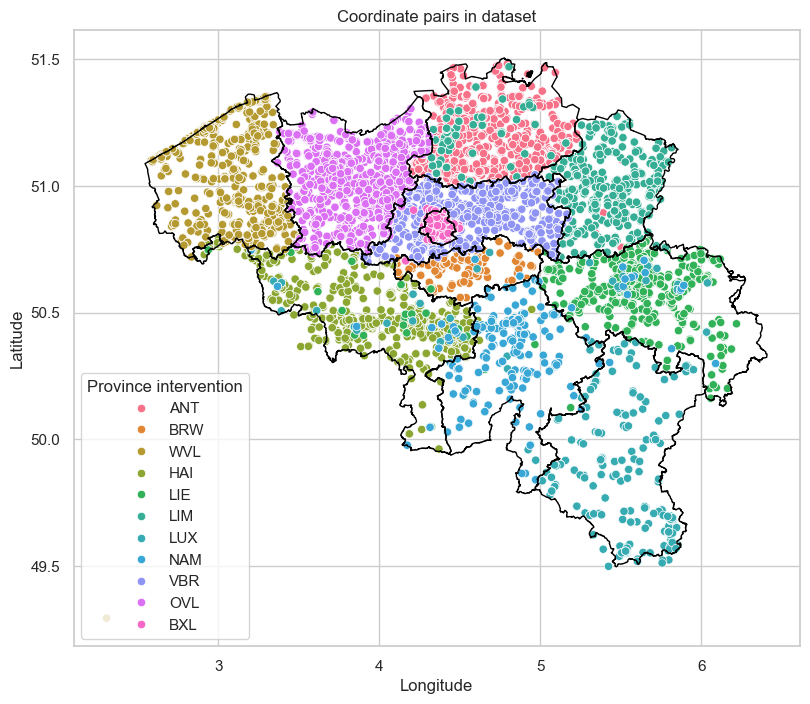

In [23]:
coordinates = interventions_TOTAL[['Longitude', 'Latitude', 'Province intervention']]
coordinates.reset_index(drop=True, inplace=True) # Indices must be reset, because there were duplicates present
# Plot distribution of interventions per province
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=coordinates, x='Longitude', y='Latitude', hue='Province intervention',ax=ax).set(xlabel='Longitude', ylabel='Latitude', title='Coordinate pairs in dataset')
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

#### 5.3.2 Assign correct provinces to the intervention locations

Apparantly, not all provinces are assigned correctly in the given dataset.
1. Create a new variable in which the correct province name is assigned.
2. In order to avoid missing values for the intervention provinces, assign to the 32 observations, wich fall just outside of Belgium, the province name of the nearest province.
3. Check visually if the correct province names have been assigned.
4. Drop the original column 'Province interventions' from the dataset.

In [24]:
interventions_TOTAL_with_provinces = assign_province(df=interventions_TOTAL, boundaries=belgium_with_provinces_boundary)

In [25]:
print('Missing values per variable: \n', interventions_TOTAL_with_provinces.isnull().sum())

Missing values per variable: 
 Mission ID                  0
Latitude                    0
Longitude                   0
Intervention                0
Eventlevel                  0
T3-T0                    1923
EventType                   0
Vector type                80
Province intervention       0
AED                         0
Ambulance                   0
Mug                         0
PIT                         0
Province                   32
dtype: int64


In [26]:
# 32 Interventions were just outside of Belgium, assign them to nearest Province
interventions_TOTAL_with_provinces = assign_nearest_province(interventions_TOTAL_with_provinces, belgium_with_provinces_boundary)
print('Missing values per variable: \n', interventions_TOTAL_with_provinces.isnull().sum())

Missing values per variable: 
 Mission ID                  0
Latitude                    0
Longitude                   0
Intervention                0
Eventlevel                  0
T3-T0                    1923
EventType                   0
Vector type                80
Province intervention       0
AED                         0
Ambulance                   0
Mug                         0
PIT                         0
Province                    0
dtype: int64


<Axes: title={'center': 'Coordinate pairs in dataset'}, xlabel='Longitude', ylabel='Latitude'>

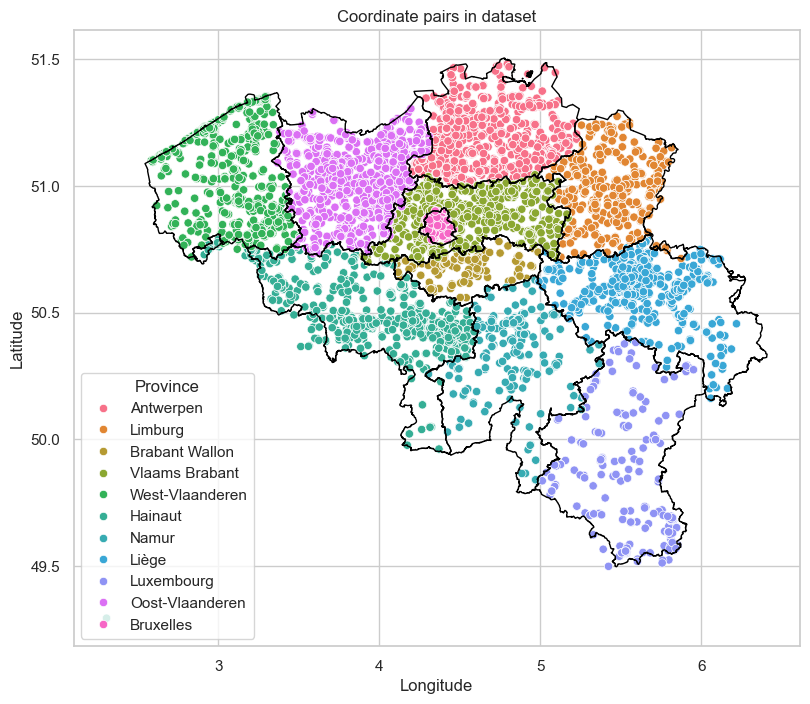

In [27]:
coordinates = interventions_TOTAL_with_provinces[['Longitude', 'Latitude', 'Province']]

# Plot (re)distribution of interventions per province
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=coordinates, x='Longitude', y='Latitude', hue='Province',ax=ax).set(xlabel='Longitude', ylabel='Latitude', title='Coordinate pairs in dataset')
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

In [28]:
# Drop 'Province intervention column'
interventions_TOTAL_with_provinces = interventions_TOTAL_with_provinces.drop(columns='Province intervention')
interventions_TOTAL_with_provinces.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province
0,10221520047,51.20685,5.13662,1,1,18.884917,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen
1,10221520095,51.24848,4.43869,1,1,4.238700,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen
2,10221520095,51.24848,4.43869,1,1,12.612550,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen
3,10221520224,51.28273,4.42134,1,1,13.427900,P003 - Cardiac arrest,MUG,0,0,0,0,Antwerpen
4,10221520224,51.28273,4.42134,1,1,36.619500,P003 - Cardiac arrest,Ambulance,0,0,0,0,Antwerpen


## 4. Preprocessing AED Datasets

1. Only keep the publically available AEDs in the dataset.
2. Correct format of the latitude and longitude coordinates.
3. Create new variables: Intervention, AED, Ambulance, Mug, PIT (binary indicator variables), Eventlevel, EventType, T3-T0, Vector type and Mission ID.
4. Assign the province names depending on the location of the AED to the dataset in a new column 'Province'.
5. Select only several number of variables to go further with.

In [29]:
# Discard non-public aed locations and also those of which no data is available
yes_values = ['Y', 'y', 'Oui-Ja', 'Ja', 'Oui', 'J', np.nan]
aed_total = aed_total[
    aed_total['public'].isin(yes_values)]  

# Correcting coordinates
aed_total['Latitude'] = aed_total['latitude'].apply(correct_latitude)
aed_total['Longitude'] = aed_total['longitude'].apply(correct_longitude)

# Creatin new variables Intervention, AED, Ambulance, Mug, T3-T0, EventType and EventLevel
aed_total['Intervention'] = 0
aed_total['AED'] = 1
aed_total['Eventlevel'] = np.nan
aed_total['EventType'] = 'AED'
aed_total['T3-T0'] = pd.NaT
aed_total['Ambulance'] = 0
aed_total['Mug'] = 0
aed_total['PIT'] = 0
aed_total['Vector type'] = 'AED'
aed_total['Mission ID'] = 0

In [30]:
# Assign provinces to AED locations
aed_total_with_provinces = assign_province(df=aed_total, boundaries=belgium_with_provinces_boundary)

In [31]:
# Select only several variables for further analysis
aed_total_with_provinces = aed_total_with_provinces[
    ['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 'EventType', 
     'Vector type', 'AED', 'Ambulance', 'Mug', 'PIT', 'Province']]

In [32]:
aed_total_with_provinces.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province
0,0,50.576960,4.065581,0,NaN,NaT,AED,AED,1,0,0,0,Hainaut
1,0,50.612604,5.737664,0,NaN,NaT,AED,AED,1,0,0,0,Liège
2,0,50.644636,5.573312,0,NaN,NaT,AED,AED,1,0,0,0,Liège
3,0,50.285338,5.784183,0,NaN,NaT,AED,AED,1,0,0,0,Liège
4,0,50.646549,5.570095,0,NaN,NaT,AED,AED,1,0,0,0,Liège


## 5. Preprocessing Ambulance Dataset

1. Correct format of the latitude and longitude coordinates.
2. Create new variables: Intervention, AED, Ambulance, Mug, PIT (binary indicator variables), Eventlevel, EventType, T3-T0, Vector type and Mission ID.
4. Assign the province names depending on the location of the Ambulances to the dataset in a new column 'Province'.
5. Select only several number of variables to go further with.

In [33]:
# Correcting coordinates
ambulance['Latitude'] = ambulance['latitude'].apply(correct_latitude)
ambulance['Longitude'] = ambulance['longitude'].apply(correct_longitude)

# Creating new variables Intervention, AED, Eventlevel, EventType, T3-T0, Ambulance and Mug
ambulance['Intervention'] = 0
ambulance['AED'] = 0
ambulance['Eventlevel'] = np.nan
ambulance['EventType'] = 'Ambulance'
ambulance['T3-T0'] = pd.NaT
ambulance['Ambulance'] = 1
ambulance['Mug'] = 0
ambulance['PIT'] = 0
ambulance['Vector type'] = 'Ambulance'
ambulance['Mission ID'] = 0

In [34]:
# Assign provinces to Ambulance locations
ambulance_with_provinces = assign_province(df=ambulance, boundaries=belgium_with_provinces_boundary)

In [35]:
# Select only several variables for further analysis
ambulance_with_provinces = ambulance_with_provinces[
    ['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 'EventType', 
     'Vector type', 'AED', 'Ambulance', 'Mug', 'PIT', 'Province']]

In [36]:
ambulance_with_provinces.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province
0,0,51.215516,4.443788,0,NaN,NaT,Ambulance,Ambulance,0,1,0,0,Antwerpen
1,0,51.178831,4.361948,0,NaN,NaT,Ambulance,Ambulance,0,1,0,0,Antwerpen
2,0,51.232810,4.377237,0,NaN,NaT,Ambulance,Ambulance,0,1,0,0,Antwerpen
3,0,51.315516,4.321506,0,NaN,NaT,Ambulance,Ambulance,0,1,0,0,Antwerpen
4,0,51.213623,4.405718,0,NaN,NaT,Ambulance,Ambulance,0,1,0,0,Antwerpen


## 6. Preprocessing Mug Dataset

1. Correct the format of the latitude and longitude coordinates.
2. Create new variables: Intervention, AED, Ambulance, Mug, PIT (binary indicator variables), Eventlevel, EventType, T3-T0, Vector type and Mission ID.
4. Assign the province names depending on the location of the MUGs to the dataset in a new column 'Province'.
5. Select only several number of variables to go further with.

In [37]:
# Correcting coordinates
mug1['Latitude'] = mug1['latitude'].apply(correct_latitude)
mug1['Longitude'] = mug1['longitude'].apply(correct_longitude)

# Creating new variables Intervention, AED, Eventlevel, EventType, T3-T0, Ambulance and Mug
mug1['Intervention'] = 0
mug1['AED'] = 0
mug1['Eventlevel'] = np.nan
mug1['EventType'] = 'Mug'
mug1['T3-T0'] = pd.NaT
mug1['Ambulance'] = 0
mug1['Mug'] = 1
mug1['PIT'] = 0
mug1['Vector type'] = 'MUG'
mug1['Mission ID'] = 0

In [38]:
# Assign provinces to Ambulance locations
mug_with_provinces = assign_province(df=mug1, boundaries=belgium_with_provinces_boundary)

In [39]:
# Select only several variables for further analysis
mug_with_provinces = mug_with_provinces[['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 'EventType', 
                                         'Vector type', 'AED', 'Ambulance', 'Mug', 'PIT', 'Province']]

In [40]:
mug_with_provinces.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province
0,0,51.133301,5.162843,0,NaN,NaT,Mug,MUG,0,0,1,0,Antwerpen
1,0,51.206704,4.414373,0,NaN,NaT,Mug,MUG,0,0,1,0,Antwerpen
2,0,51.206492,4.470635,0,NaN,NaT,Mug,MUG,0,0,1,0,Antwerpen
3,0,51.182009,4.420858,0,NaN,NaT,Mug,MUG,0,0,1,0,Antwerpen
4,0,51.175704,4.412289,0,NaN,NaT,Mug,MUG,0,0,1,0,Antwerpen


## 7. Preprocessing PIT Dataset

### 7.1 Adding locations of PITs in Latitudes and Longitudes to dataframe

An external dataset was found online with the exact coordinates for the PIT locations. These latitudes and longitudes are merged to the original dataset based on the unit id of the PIT.

In [41]:
# Extract 9-character code from 'unit_id' and 'Medical resource' from both PIT datasets and collect them in new variable
pit['id'] = pit['unit_id'].str.extract(r'(\w{9})')
pit_locations['id'] = pit_locations['Medical resource'].str.extract(r'Team: (\w{9})')

# Merge the two DataFrames based on the common 'code' column
pit_merged = pd.merge(pit, pit_locations, on='id', how='inner')

### 7.2 Other steps

1. Create new variables: Intervention, AED, Ambulance, Mug, PIT (binary indicator variables), Eventlevel, EventType, T3-T0, Vector type and Mission ID.
2. Assign the province names depending on the location of the Ambulances to the dataset in a new column 'Province'.
3. Select only several number of variables to go further with.

In [42]:
# Creating new variables Intervention, AED, Eventlevel, EventType, T3-T0, Ambulance and Mug
pit_merged['Intervention'] = 0
pit_merged['AED'] = 0
pit_merged['Eventlevel'] = np.nan
pit_merged['EventType'] = 'PIT'
pit_merged['T3-T0'] = pd.NaT
pit_merged['Ambulance'] = 0
pit_merged['Mug'] = 0
pit_merged['PIT'] = 1
pit_merged['Vector type'] = 'PIT'
pit_merged['Mission ID'] = 0

In [43]:
# Assign provinces to Ambulance locations
pit_merged_with_provinces = assign_province(df=pit_merged, boundaries=belgium_with_provinces_boundary)

In [44]:
# Select only several variables for further analysis
pit_merged_with_provinces = pit_merged_with_provinces[['Mission ID', 'Latitude', 'Longitude', 'Intervention', 'Eventlevel', 'T3-T0', 
                                                       'EventType', 'Vector type', 'AED', 'Ambulance', 'Mug', 'PIT', 'Province']]
pit_merged_with_provinces.head(5)

,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province
0,0,51.105673,4.370804,0,NaN,NaT,PIT,PIT,0,0,0,1,Antwerpen
1,0,50.987058,3.527023,0,NaN,NaT,PIT,PIT,0,0,0,1,Oost-Vlaanderen
2,0,51.231494,4.415306,0,NaN,NaT,PIT,PIT,0,0,0,1,Antwerpen
3,0,51.132641,4.564068,0,NaN,NaT,PIT,PIT,0,0,0,1,Antwerpen
4,0,51.186468,5.113201,0,NaN,NaT,PIT,PIT,0,0,0,1,Antwerpen


## 8. Concatenating all datasets together for RTA and AED Placement

1. Concatenate all preprocessed datasets from before together to one big dataset containing all relevant locations.
2. Print some general information about the large dataset. 

In [45]:
total_df = pd.concat([interventions_TOTAL_with_provinces, aed_total_with_provinces, 
                      ambulance_with_provinces, mug_with_provinces, pit_merged_with_provinces], axis=0)

In [46]:
print('Unique number of values Latitude values: ', len(list(total_df['Latitude'].unique())))
print('\nUnique number of values Longitude values: ', len(list(total_df['Longitude'].unique())))
print('\nUnique values eventlevels', total_df['Eventlevel'].unique())
cross_tab = pd.crosstab(index=pd.Categorical(total_df["Eventlevel"]), columns='count')
print('\nCross table of Event Levels: \n', cross_tab)

max_responseTime = total_df['T3-T0'].max()
print(f'\nMaximum Response Time for total_df: {max_responseTime}')
print('\nMissing values per variable: \n', total_df.isnull().sum())
print('\nTotal Length of the Dataset: ', len(total_df))
print('\nTypes of variables in dataset: \n', total_df.dtypes)

Unique number of values Latitude values:  18115

Unique number of values Longitude values:  18166

Unique values eventlevels [ 1.  2.  0.  5.  7.  6. nan]

Cross table of Event Levels: 
 col_0  count
row_0       
0.0     1588
1.0     9107
2.0      640
5.0      907
6.0       63
7.0        6

Maximum Response Time for total_df: 80267.83333333333

Missing values per variable: 
 Mission ID          0
Latitude            0
Longitude           0
Intervention        0
Eventlevel      14382
T3-T0           16305
EventType           0
Vector type        80
AED                 0
Ambulance           0
Mug                 0
PIT                 0
Province          101
dtype: int64

Total Length of the Dataset:  26693

Types of variables in dataset: 
 Mission ID        int64
Latitude        float64
Longitude       float64
Intervention      int64
Eventlevel      float64
T3-T0            object
EventType        object
Vector type      object
AED               int64
Ambulance         int64
Mug         

## 9. Visual inspection of the parameters

### 9.1 Plot distribution in the form of histograms of some parameters

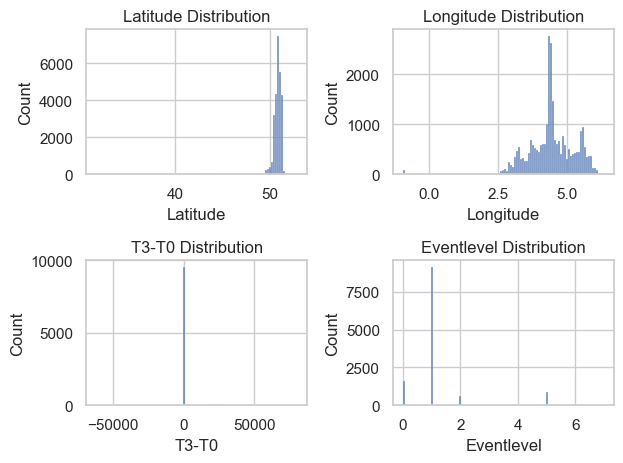

In [47]:
# Setting the style for the plots
sns.set(style="whitegrid")
draw_histograms(total_df, total_df[['Latitude', 'Longitude', 'T3-T0', 'Eventlevel']], 2, 2)

There are 42 negative response times in the dataset


,Mission ID,Latitude,Longitude,Intervention,Eventlevel,T3-T0,EventType,Vector type,AED,Ambulance,Mug,PIT,Province
6847,21221530192,50.928019,4.535123,1,1.0,-61990.383333,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,MUG,0,0,0,0,Vlaams Brabant
6848,21221530192,50.928019,4.535123,1,1.0,-61990.383333,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant
6894,21221610127,50.820890,4.507365,1,1.0,-57882.716667,P003 - HARTSTILSTAND - DOOD - OVERLEDEN,Ambulance,0,0,0,0,Vlaams Brabant


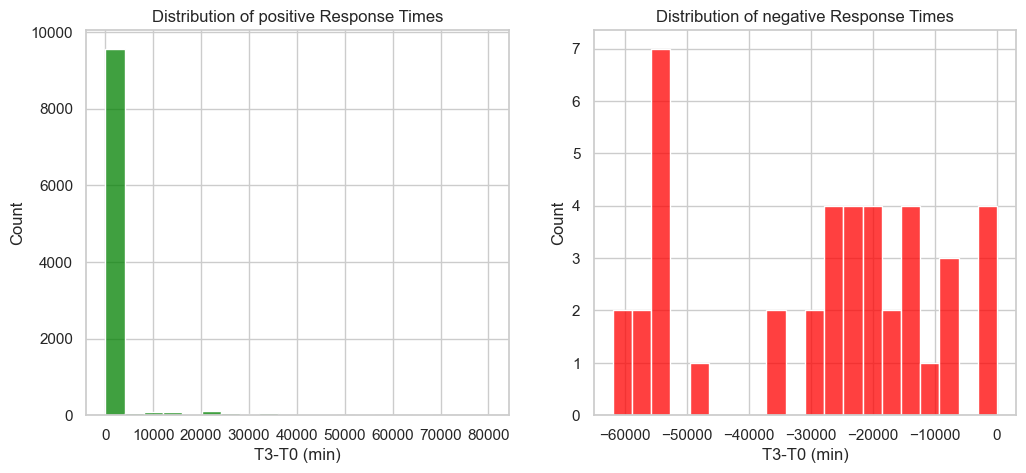

In [48]:
# Only plot Response Times for intervention locations
intervention_locations = total_df[total_df['Intervention'] == 1]

# Setting the style for the plots
sns.set(style="whitegrid")

# Create separate DataFrames for positive and negative values
positive_values = intervention_locations[intervention_locations['T3-T0'] >= 0]
negative_values = intervention_locations[intervention_locations['T3-T0'] < 0]

# Create the histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=positive_values, x='T3-T0', bins=20, color='green', label='Positive Values', ax=axes[0]).set(
    title='Distribution of positive Response Times', xlabel='T3-T0 (min)')
sns.histplot(data=negative_values, x='T3-T0', bins=20, color='red', label='Negative Values', ax=axes[1]).set(
    title='Distribution of negative Response Times', xlabel='T3-T0 (min)')

# Count number of negative response times
print('There are', len(negative_values), 'negative response times in the dataset')
negative_values.head(3)

[Text(0.5, 0, 'Longitude'),
 Text(0, 0.5, 'Latitude'),
 Text(0.5, 1.0, 'Coordinate pairs in dataset')]

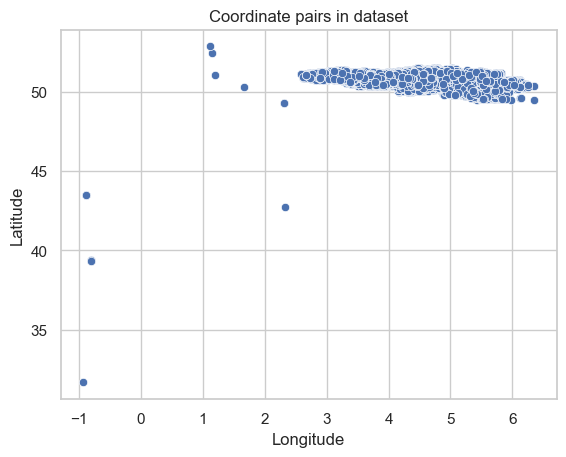

In [49]:
coordinates = total_df[['Longitude', 'Latitude']]
coordinates.reset_index(drop=True, inplace=True) # Indices must be reset, because there were duplicates present
sns.scatterplot(data=coordinates, x='Longitude', y='Latitude').set(xlabel='Longitude', ylabel='Latitude', title='Coordinate pairs in dataset')

### 9.1 Remove coordinate pairs which lie far outsdide of Belgium

Belgian coordinates found from source: https://www.belgium.be/en/about_belgium/country/geography 

Citate: 'Belgium spans 2 degrees in latitude, from 51 degrees 30 minutes N at Meerle (northernmost point) to 49 degrees 30 minutes N at Torgny (southernmost point). In longitude, it spans less than 4 degrees, from 2 degrees 33 minutes E to 6 degrees 24 minutes E.'

The nine coordinate pairs which fall far outside of Belgium (seen on plot above) are removed from dataset.

In [51]:
# Remove locations outside of Belgium from the dataset
total_df = total_df[total_df.apply(lambda row: is_within_belgium(row['Latitude'], row['Longitude']), axis=1)]

<Axes: title={'center': 'Coordinate pairs in dataset'}, xlabel='Longitude', ylabel='Latitude'>

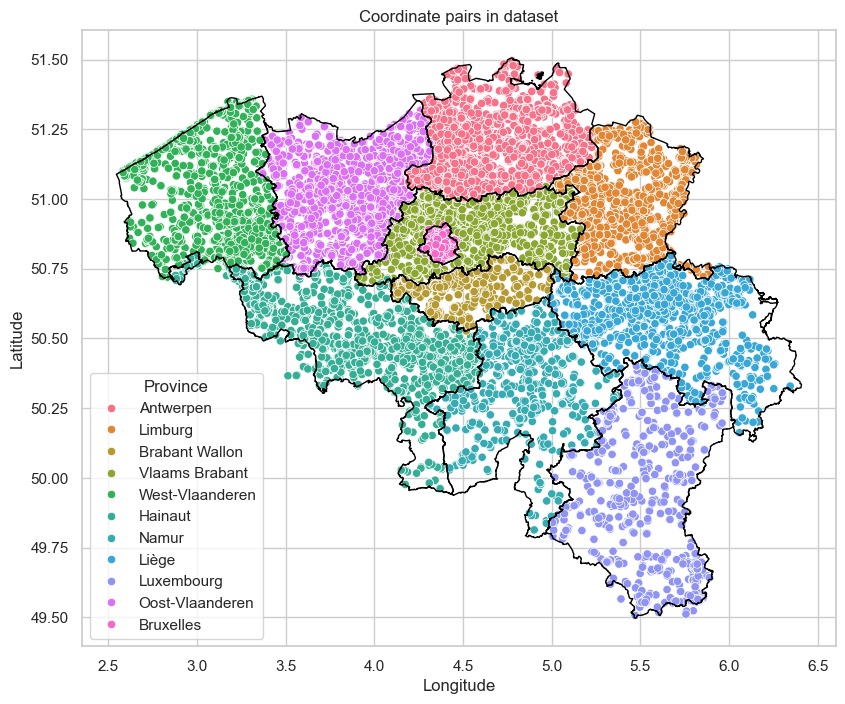

In [52]:
coordinates = total_df[['Longitude', 'Latitude', 'Province']]

# Plot (re)distribution of interventions per province
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=coordinates, x='Longitude', y='Latitude', hue='Province',ax=ax).set(xlabel='Longitude', ylabel='Latitude', title='Coordinate pairs in dataset')
belgium_with_provinces_boundary.plot(ax=ax, facecolor='none', edgecolor='black')

### 9.2 Set negative Response Times to pd.NaT

1. Set the negative response times to missing variables of the type datetime.
2. Plot distribution of response times split up over the three vector types.

In [53]:
# Transform negative time difference to NaT
total_df.loc[total_df['T3-T0'] < 0, 'T3-T0'] = pd.NaT

[Text(0.5, 1.0, 'Logscale of Response Times'), Text(0.5, 0, 'Log(T3-T0)')]

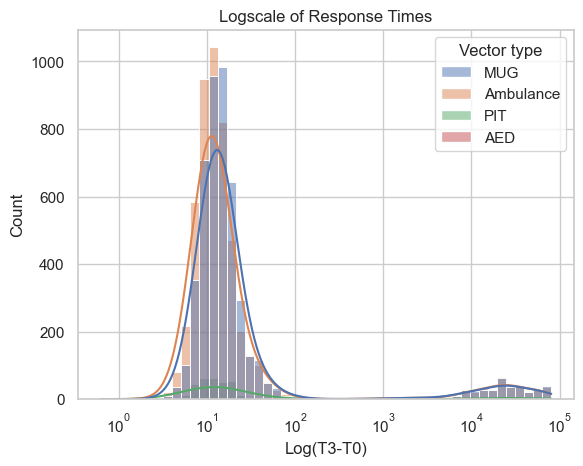

In [54]:
total_df.reset_index(drop=True, inplace=True) # Reset index of dataframe

# Histogram of Response Time distribution
sns.histplot(data=total_df, x='T3-T0', bins=50, log_scale=True, kde=True, hue='Vector type').set(title='Logscale of Response Times', xlabel='Log(T3-T0)') 
# Seriously long Response times found. Seems there is a group of outliers.

## 10. Save new Dataset to the repository

In [56]:
total_df.to_csv(output_data_path, index=False)